In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# STEP 1 — Install Required Libraries

In [1]:
!pip install flwr torch torchvision scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 752.9/752.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 92.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: pathspec
    Found existing installation: pathspec 1.0.4
    Uninstalling pathspec-1.0.4:
      Successfully uninstalled pathspec-1.0.4
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.76.0
    Uninstalling grpcio-1.76.0:
      Successfully uninstalled grpcio-1.76.0
  Attempting uninstall: crypto

# STEP 2 — Import Libraries

In [2]:
import os
import glob
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from PIL import Image
import flwr as fl
import matplotlib.pyplot as plt

# STEP 3 — Set Device

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


# STEP 4 — Define Dataset Paths

In [4]:
train_dir = "/kaggle/input/datasets/takeoff012/skin-prediction/test"
test_dir = "/kaggle/input/datasets/takeoff012/skin-prediction/test"

# STEP 5 — Load Classes Automatically

In [5]:
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)
class_to_idx = {cls: i for i, cls in enumerate(classes)}

print("Classes:", classes)

Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


# STEP 6 — Define Image Transforms

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# STEP 7 — Create Custom Dataset

In [7]:
class SkinDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        
        for cls in classes:
            folder = os.path.join(root_dir, cls)
            for img_path in glob.glob(os.path.join(folder, "*")):
                self.samples.append((img_path, class_to_idx[cls]))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# STEP 8 — Load Full Dataset

In [8]:
full_train_dataset = SkinDataset(train_dir, train_transform)
test_dataset = SkinDataset(test_dir, test_transform)

print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))

Train size: 5434
Test size: 5434


# STEP 9 — Split Dataset Into Clients (Balanced)

In [9]:
num_clients = 5

labels = [label for _, label in full_train_dataset.samples]
skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=42)

client_datasets = []

for _, idx in skf.split(np.zeros(len(labels)), labels):
    client_datasets.append(Subset(full_train_dataset, idx))

print("Clients created:", len(client_datasets))

Clients created: 5


# STEP 10 — Define ResNet50 Model

In [10]:
class ResNetModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
    
    def forward(self, x):
        return self.model(x)

# STEP 11 — Training Function

In [11]:
def train(model, loader, epochs=2):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0003)
    
    for epoch in range(epochs):
        correct = 0
        total = 0
        running_loss = 0
        
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(loader):.4f}, Accuracy: {100*correct/total:.2f}%")

# STEP 12 — Test Function

In [12]:
def test(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

# STEP 13 — Flower Client

In [13]:
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, dataset):
        self.model = ResNetModel(num_classes).to(DEVICE)
        self.dataset = dataset
    
    def get_parameters(self, config):
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]
    
    def set_parameters(self, parameters):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = {k: torch.tensor(v) for k, v in params_dict}
        self.model.load_state_dict(state_dict, strict=True)
    
    def fit(self, parameters, config):
        self.set_parameters(parameters)
        loader = DataLoader(self.dataset, batch_size=32, shuffle=True)
        train(self.model, loader, epochs=2)
        return self.get_parameters(config), len(self.dataset), {}
    
    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loader = DataLoader(self.dataset, batch_size=32)
        accuracy = test(self.model, loader)
        return float(0.0), len(self.dataset), {"accuracy": float(accuracy)}

# STEP 14 — Client Function

In [14]:
def client_fn(cid):
    return FlowerClient(client_datasets[int(cid)])

# STEP 15 — Start Federated Learning

In [20]:
# Number of federated rounds
num_rounds = 10

# Initialize global model
global_model = ResNetModel(num_classes).to(DEVICE)

# Convert model parameters to numpy
global_parameters = [
    val.cpu().detach().numpy() 
    for val in global_model.state_dict().values()
]

for round_num in range(num_rounds):
    print(f"\n================ ROUND {round_num+1} ================")

    client_weights = []
    client_sizes = []

    # Train each client sequentially
    for i in range(num_clients):
        client = FlowerClient(client_datasets[i])

        # Send global weights
        client.set_parameters(global_parameters)

        # Local training
        loader = DataLoader(client_datasets[i], batch_size=32, shuffle=True)
        train(client.model, loader, epochs=2)

        # Collect updated weights
        weights = client.get_parameters({})
        client_weights.append(weights)
        client_sizes.append(len(client_datasets[i]))

    # -------- Federated Averaging --------
    new_global_weights = []

    for weights_list_tuple in zip(*client_weights):

        first_weight = weights_list_tuple[0]

        # If parameter is integer (BatchNorm tracking buffer)
        if first_weight.dtype == np.int64:
            new_global_weights.append(first_weight)
            continue

        # Weighted average for float parameters
        weighted_sum = np.zeros_like(first_weight, dtype=np.float32)

        for client_idx, weights in enumerate(weights_list_tuple):
            weighted_sum += weights.astype(np.float32) * (
                client_sizes[client_idx] / sum(client_sizes)
            )

        new_global_weights.append(weighted_sum)

    global_parameters = new_global_weights

print("\nFederated Training Completed!")


================ ROUND 1 ================
Epoch 1, Loss: 1.3685, Accuracy: 47.19%
Epoch 2, Loss: 0.9858, Accuracy: 60.81%
Epoch 1, Loss: 1.3757, Accuracy: 50.51%
Epoch 2, Loss: 0.9528, Accuracy: 66.51%
Epoch 1, Loss: 1.3873, Accuracy: 50.23%
Epoch 2, Loss: 1.0458, Accuracy: 61.27%
Epoch 1, Loss: 1.4352, Accuracy: 47.29%
Epoch 2, Loss: 1.0119, Accuracy: 62.56%
Epoch 1, Loss: 1.3962, Accuracy: 47.97%
Epoch 2, Loss: 1.0013, Accuracy: 62.98%

================ ROUND 2 ================
Epoch 1, Loss: 1.1732, Accuracy: 56.39%
Epoch 2, Loss: 0.9573, Accuracy: 65.69%
Epoch 1, Loss: 1.0832, Accuracy: 59.80%
Epoch 2, Loss: 0.8513, Accuracy: 68.72%
Epoch 1, Loss: 1.0780, Accuracy: 60.35%
Epoch 2, Loss: 0.9070, Accuracy: 65.78%
Epoch 1, Loss: 1.1439, Accuracy: 56.12%
Epoch 2, Loss: 0.9469, Accuracy: 66.15%
Epoch 1, Loss: 1.1218, Accuracy: 58.47%
Epoch 2, Loss: 0.8995, Accuracy: 64.18%

================ ROUND 3 ================
Epoch 1, Loss: 1.0037, Accuracy: 63.02%
Epoch 2, Loss: 0.7974, Accuracy

# STEP 16 — Final Evaluation on Test Dataset

In [21]:
# Load final aggregated weights into global model
state_dict = zip(global_model.state_dict().keys(), global_parameters)
state_dict = {k: torch.tensor(v) for k, v in state_dict}
global_model.load_state_dict(state_dict, strict=True)

# Move to device
global_model = global_model.to(DEVICE)
global_model.eval()

# Test loader
test_loader = DataLoader(test_dataset, batch_size=32)

correct = 0
total = 0
test_loss = 0
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = global_model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_accuracy = 100 * correct / total
test_loss = test_loss / len(test_loader)

print("Final Test Accuracy:", final_accuracy)
print("Final Test Loss:", test_loss)

Final Test Accuracy: 91.77401545822599
Final Test Loss: 0.23901186020332663


# STEP 17 — Modify Training Loop to Store Loss

In [23]:
import numpy as np
from torch.utils.data import DataLoader

# Track metrics
round_train_losses = []
round_test_accuracies = []

num_rounds = 10  # You can change as needed

# Initialize global model
global_model = ResNetModel(num_classes).to(DEVICE)

# Convert model parameters to numpy arrays
global_parameters = [val.cpu().detach().numpy() for val in global_model.state_dict().values()]

for round_num in range(num_rounds):
    print(f"\n================ ROUND {round_num+1} ================")

    client_weights = []
    client_sizes = []
    total_loss = 0

    # Train each client sequentially
    for i in range(num_clients):
        client = FlowerClient(client_datasets[i])
        client.set_parameters(global_parameters)

        loader = DataLoader(client_datasets[i], batch_size=32, shuffle=True)

        # Local training
        model = client.model
        model.train()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0003)

        running_loss = 0.0
        for epoch in range(2):  # Local epochs per round
            for images, labels in loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

        # Average loss for this client
        avg_loss = running_loss / len(loader)
        total_loss += avg_loss

        # Get updated weights
        weights = client.get_parameters({})
        client_weights.append(weights)
        client_sizes.append(len(client_datasets[i]))

        print(f"Client {i} - Avg Loss: {avg_loss:.4f}")

    # Round average training loss
    round_train_loss = total_loss / num_clients
    round_train_losses.append(round_train_loss)
    print(f"Round {round_num+1} Average Training Loss: {round_train_loss:.4f}")

    # =========================
    # Federated Averaging (FIXED)
    # =========================
    new_global_weights = []

    for weights_list_tuple in zip(*client_weights):
        first_weight = weights_list_tuple[0]

        # If parameter is integer (like num_batches_tracked), just take first client’s value
        if np.issubdtype(first_weight.dtype, np.integer):
            new_global_weights.append(first_weight)
            continue

        # Float parameters: compute weighted average
        weighted_sum = np.zeros_like(first_weight, dtype=np.float32)
        for client_idx, weights in enumerate(weights_list_tuple):
            weighted_sum += weights.astype(np.float32) * (
                client_sizes[client_idx] / sum(client_sizes)
            )
        new_global_weights.append(weighted_sum)

    # Update global parameters for next round
    global_parameters = new_global_weights

print("\nFederated Training Completed!")


================ ROUND 1 ================
Client 0 - Avg Loss: 2.4483
Client 1 - Avg Loss: 2.2926
Client 2 - Avg Loss: 2.3799
Client 3 - Avg Loss: 2.4633
Client 4 - Avg Loss: 2.3780
Round 1 Average Training Loss: 2.3924

================ ROUND 2 ================
Client 0 - Avg Loss: 2.1060
Client 1 - Avg Loss: 1.9432
Client 2 - Avg Loss: 1.9601
Client 3 - Avg Loss: 2.0553
Client 4 - Avg Loss: 2.0453
Round 2 Average Training Loss: 2.0220

================ ROUND 3 ================
Client 0 - Avg Loss: 1.8464
Client 1 - Avg Loss: 1.7267
Client 2 - Avg Loss: 1.7360
Client 3 - Avg Loss: 1.8142
Client 4 - Avg Loss: 1.7706
Round 3 Average Training Loss: 1.7788

================ ROUND 4 ================
Client 0 - Avg Loss: 1.6823
Client 1 - Avg Loss: 1.5279
Client 2 - Avg Loss: 1.5842
Client 3 - Avg Loss: 1.6761
Client 4 - Avg Loss: 1.6099
Round 4 Average Training Loss: 1.6161

================ ROUND 5 ================
Client 0 - Avg Loss: 1.4760
Client 1 - Avg Loss: 1.4578
Client 2 - Avg Lo

# STEP 18 — Final Evaluation with Full Metrics

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load global weights
state_dict = zip(global_model.state_dict().keys(), global_parameters)
state_dict = {k: torch.tensor(v) for k, v in state_dict}
global_model.load_state_dict(state_dict, strict=True)

global_model.eval()

test_loader = DataLoader(test_dataset, batch_size=32)

all_preds = []
all_labels = []
test_loss = 0

criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = global_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / len(test_loader)

print("Final Test Loss:", test_loss)

Final Test Loss: 0.2622592223534251


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# STEP 19 — Classification Report

In [25]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))


Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.83      0.72      0.77       336
           10. Warts Molluscum and other Viral Infections - 2103       0.93      0.78      0.85       421
                                              2. Melanoma 15.75k       0.98      0.98      0.98       628
                                    3. Atopic Dermatitis - 1.25k       0.77      0.84      0.80       252
                              4. Basal Cell Carcinoma (BCC) 3323       0.93      1.00      0.96       665
                                 5. Melanocytic Nevi (NV) - 7970       0.98      0.98      0.98      1594
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.95      0.86      0.90       416
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.89      0.71      0.79       411
          8. Seborrh

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# STEP 20 — Confusion Matrix

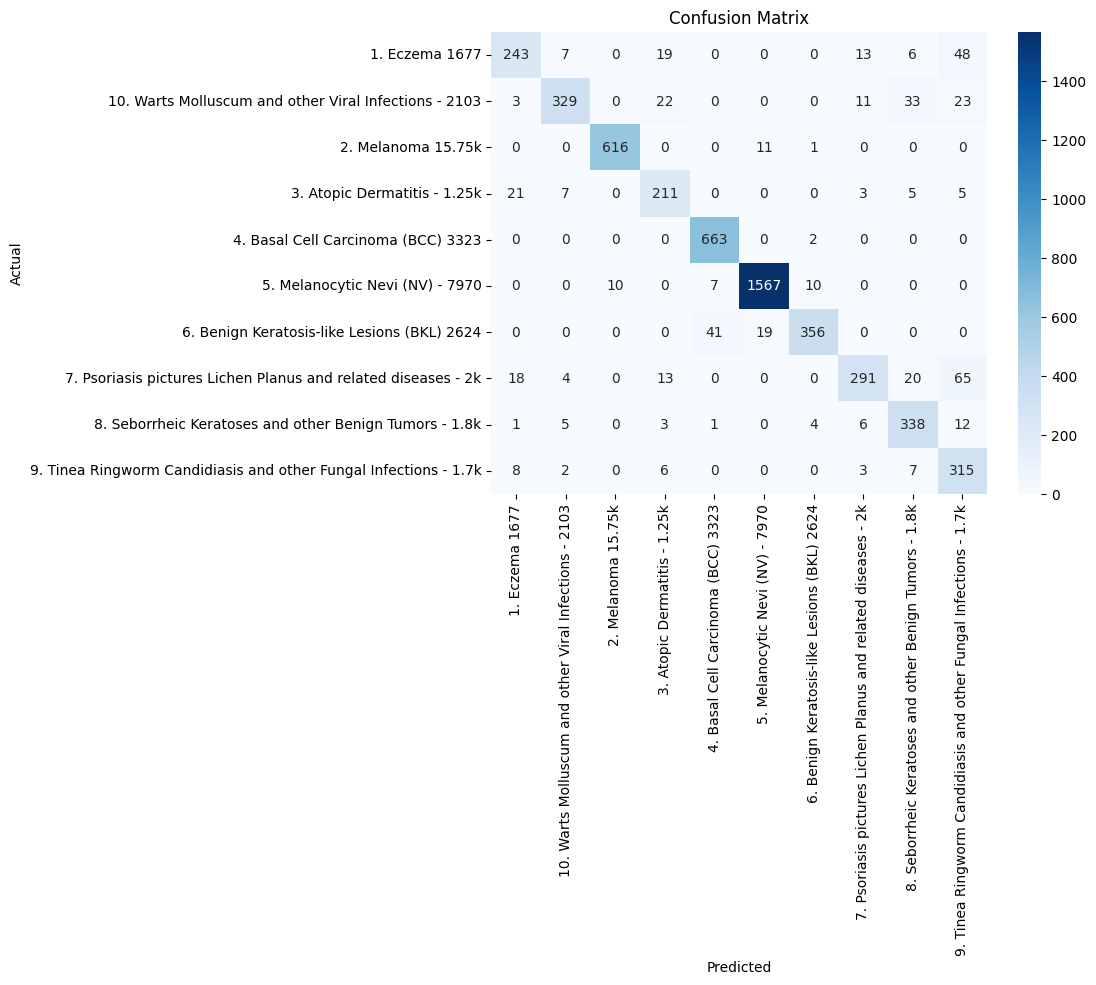

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# STEP 21 — Plot Training Loss Curve

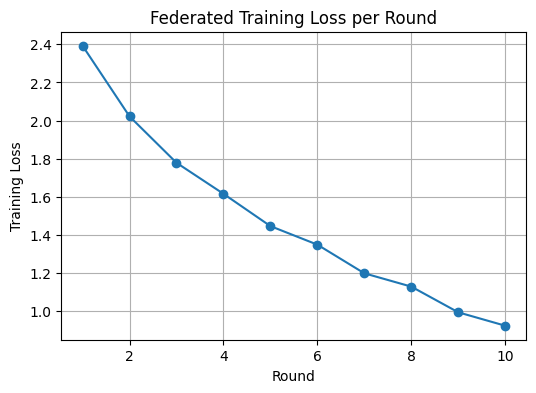

In [27]:
plt.figure(figsize=(6,4))
plt.plot(range(1, num_rounds+1), round_train_losses, marker='o')
plt.title("Federated Training Loss per Round")
plt.xlabel("Round")
plt.ylabel("Training Loss")
plt.grid()
plt.show()

# STEP 22 — Save Final Model

In [28]:
# Define save path
model_path = "/kaggle/working/federated_resnet50_skin_model.pth"

# Save model checkpoint
torch.save({
    'model_state_dict': global_model.state_dict(),
    'num_classes': num_classes,
    'class_names': classes,
    'training_loss_per_round': round_train_losses if 'round_train_losses' in globals() else None,
    'final_test_loss': test_loss,
    'final_accuracy': final_accuracy,
}, model_path)

print("Model saved successfully at:", model_path)

Model saved successfully at: /kaggle/working/federated_resnet50_skin_model.pth
